### Создаём синтетический датасет

In [1]:
import torch
import matplotlib.pyplot as plt

# фиксируем seed для воспроизводимости
torch.manual_seed(42)

In [2]:
# истинные параметры (мы их знаем, модель - нет)
true_w = torch.tensor([2.0])
true_b = torch.tensor([1.0])

# генерируем входные данные: 100 точек от 0 до 10
x = torch.linspace(0, 10, 100).reshape(-1, 1)

# считаем идеальные значения без шума
y_ideal = true_w * x + true_b

Если сейчас вывести `y_ideal`, мы получим идеальную прямую. Но в реальной жизни данные всегда зашумлены. Добавим случайный шум:

In [3]:
# добавляем нормальный шум со стандартным отклонением 2
y = y_ideal + torch.randn_like(x) * 2

`torch.randn_like(x)` создаёт тензор той же формы, что и `x`, заполненный случайными числами из нормального распределения (среднее 0, дисперсия 1). Умножаем на 2, чтобы шум был заметным, но не убивал зависимость полностью.

### Смотрим, что получилось

Данные нужно визуализировать — так сразу видно, с чем имеем дело:

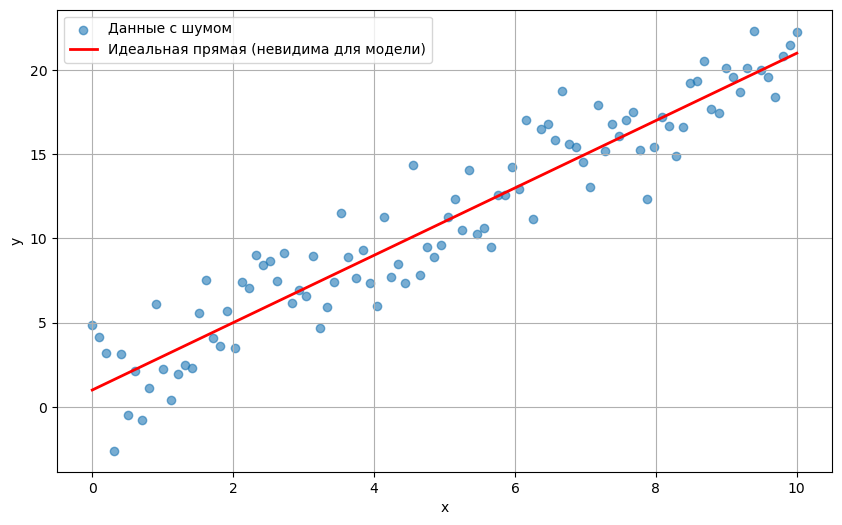

In [4]:
plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.6, label='Данные с шумом')
plt.plot(x, y_ideal, 'r-', linewidth=2, label='Идеальная прямая (невидима для модели)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

Данные готовы. Теперь создадим модель — в случае линейной регрессии это просто два числа: вес **w** и смещение **b**.

### Инициализация весов

На старте мы не знаем, какие должны быть **w** и **b**. Поэтому задаём их случайно. Единственное важное условие: для этих тензоров нужно включить `requires_grad=True`, потому что мы будем по ним считать градиенты и обновлять их.

In [5]:
# инициализируем веса случайно (равномерное распределение от -1 до 1)
w = torch.randn(1, requires_grad=True)
b = torch.randn(1, requires_grad=True)

print(f"Начальный вес w: {w.item():.4f}")
print(f"Начальное смещение b: {b.item():.4f}")

Начальный вес w: -0.5672
Начальное смещение b: -0.5706


Функция `torch.randn` даёт случайное число из нормального распределения (среднее 0, дисперсия 1). Можно использовать и другие способы инициализации, но для линейной регрессии этого достаточно.

Обратите внимание на `.item()` — это способ достать одно число из тензора размера 1, удобно для вывода.

### Прямой проход (forward pass)

Прямой проход — это вычисление предсказаний модели при текущих весах. Для линейной регрессии формула проста: `y_pred = w * x + b`

In [6]:
# прямой проход: считаем предсказания
y_pred = w * x + b

Благодаря **broadcasting** (как в NumPy), `w` (размер 1) умножается на каждый элемент `x` (размер 100×1), и `b` прибавляется к каждому результату. На выходе получается тензор той же формы, что и `x` — 100 предсказаний.

### Смотрим, что получилось

Полезно сразу визуализировать предсказания модели **до обучения**. Это поможет потом сравнить "до" и "после".

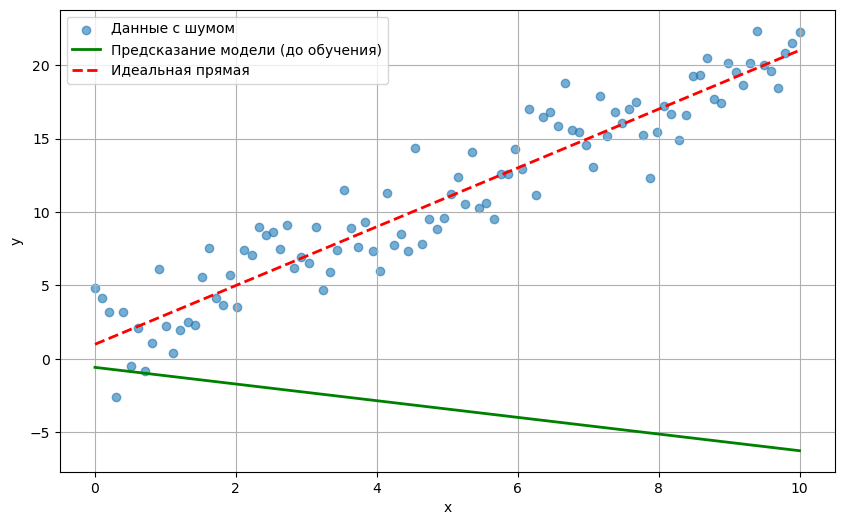

In [7]:
plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.6, label='Данные с шумом')
plt.plot(x, y_pred.detach().numpy(), 'g-', linewidth=2, label='Предсказание модели (до обучения)')
plt.plot(x, y_ideal, 'r--', linewidth=2, label='Идеальная прямая')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

Обратите внимание на `.detach().numpy()`. Мы используем `detach()`, чтобы отцепить градиенты перед превращением в NumPy (помните ошибку из Юнита 3?). Без этого `plt.plot` упадёт с ошибкой.

Скорее всего, зелёная линия будет проходить совсем не там, где нужно. Это нормально — модель ещё ничему не научилась.

### Что внутри тензоров?

Посмотрим на форму и свойства наших тензоров:

In [8]:
print(f"Форма w: {w.shape}")
print(f"Форма b: {b.shape}")
print(f"Форма x: {x.shape}")
print(f"Форма y_pred: {y_pred.shape}")
print(f"requires_grad для w: {w.requires_grad}")
print(f"requires_grad для y_pred: {y_pred.requires_grad}")

Форма w: torch.Size([1])
Форма b: torch.Size([1])
Форма x: torch.Size([100, 1])
Форма y_pred: torch.Size([100, 1])
requires_grad для w: True
requires_grad для y_pred: True


Интересный момент: `y_pred.requires_grad` тоже `True`, потому что он получен из тензоров с градиентами. Это значит, что через `y_pred` мы сможем добраться до градиентов по **w** и **b**.


## Функция потерь (loss function)

Модель сделала предсказание — зелёная линия на графике. Пока она далека от идеала. Но как измерить это математически? Нужна **функция потерь**.

### Что такое функция потерь

Функция потерь показывает, насколько сильно модель ошибается. Она принимает два аргумента — предсказания модели и правильные ответы — и возвращает одно число: величину ошибки.

Наша задача — это число минимизировать.

### Выбираем MSE (Mean Squared Error)

Для линейной регрессии классический выбор — **среднеквадратичная ошибка**. Считается она просто:

In [9]:
# MSE своими руками
loss = ((y_pred - y) ** 2).mean()


Разберём по шагам:
- `y_pred - y` — разница между предсказанием и истиной (тензор из 100 чисел)
- `** 2` — поэлементное возведение в квадрат (чтобы отрицательные ошибки не компенсировали положительные)
- `.mean()` — среднее арифметическое по всем элементам

В результате получаем одно число — скаляр. Именно скаляр нужен для `.backward()`.

### Считаем loss для нашей модели

Добавим вычисление loss в код и посмотрим, какая ошибка у случайно инициализированной модели:

In [10]:
# Прямой проход (уже сделали)
y_pred = w * x + b

# Считаем loss
loss = ((y_pred - y) ** 2).mean()

print(f"Текущий loss: {loss.item():.4f}")

Текущий loss: 270.3748


Число будет довольно большим (скорее всего, сотни). Это нормально — модель ещё не училась.

### Что хранится в loss

Посмотрим на атрибуты нашего loss:

In [11]:
print(f"Форма loss: {loss.shape}")  # torch.Size([]) — пусто, потому что скаляр
print(f"requires_grad: {loss.requires_grad}")  # True
print(f"grad_fn: {loss.grad_fn}")  # <MeanBackward0 object>

Форма loss: torch.Size([])
requires_grad: True
grad_fn: <MeanBackward0 object at 0x7fb02733e710>


##  Обратный проход и шаг градиентного спуска

Loss посчитали. Теперь нужно понять, как изменить **w** и **b**, чтобы loss уменьшился. Здесь вступает в дело autograd.

### Запускаем обратное распространение

Одной строкой кода запускаем вычисление всех градиентов:

In [12]:
# обратный проход
loss.backward()

После этого вызова в тензорах **w** и **b** появились градиенты. Давайте посмотрим на них:

In [13]:
print(f"Градиент по w: {w.grad.item():.4f}")
print(f"Градиент по b: {b.grad.item():.4f}")

Градиент по w: -188.7111
Градиент по b: -29.0522


### Что означают эти числа

Градиент показывает, **в какую сторону** и **насколько сильно** нужно изменить параметр, чтобы loss **вырос**. А нам нужно loss уменьшить, поэтому мы будем двигаться **в противоположную сторону**.

Правило обновления выглядит так:
```
новый w = старый w - learning_rate * градиент w
новый b = старый b - learning_rate * градиент b
```

### Выбираем learning rate

Скорость обучения (learning rate) — один из самых важных параметров. Слишком маленький шаг — обучение будет медленным. Слишком большой — можно перелететь минимум и loss начнёт расти.

Для начала возьмём 0.01:

In [14]:
learning_rate = 0.01

# сохраняем старые значения для сравнения
w_before = w.item()
b_before = b.item()

# обновляем веса
with torch.no_grad():  # отключаем градиенты для операции обновления
    w -= learning_rate * w.grad
    b -= learning_rate * b.grad

print(f"w: {w_before:.4f} -> {w.item():.4f}")
print(f"b: {b_before:.4f} -> {b.item():.4f}")

w: -0.5672 -> 1.3199
b: -0.5706 -> -0.2801


Обратите внимание на `with torch.no_grad():`. Это важно! Когда мы обновляем веса, мы не хотим, чтобы PyTorch строил граф вычислений для этих операций. Нам не нужно считать производные от обновления весов.

### Проверяем, что loss уменьшился

После обновления весов нужно убедиться, что наши действия принесли пользу:

In [15]:
# снова считаем предсказания и loss с новыми весами
y_pred_new = w * x + b
loss_new = ((y_pred_new - y) ** 2).mean()

print(f"Loss до обновления: {loss.item():.4f}")
print(f"Loss после обновления: {loss_new.item():.4f}")

Loss до обновления: 270.3748
Loss после обновления: 30.6885


Loss должен стать меньше. Если нет — возможно, learning rate слишком большой.

### Обнуляем градиенты

После обновления весов нужно обязательно обнулить градиенты. Иначе при следующем вызове `backward()` новые градиенты прибавятся к старым.

In [16]:
# обнуляем градиенты
w.grad.zero_()
b.grad.zero_()

print(f"Градиент w после обнуления: {w.grad}")  # tensor([0.])

Градиент w после обнуления: tensor([0.])


##  Цикл обучения

Один шаг градиентного спуска немного улучшил модель, но до идеала ещё далеко. Нужно повторить эти шаги много раз — это и есть **обучение**.

### Собираем всё в цикл

Вот полный код обучения линейной регрессии с нуля:

In [17]:
import torch
import matplotlib.pyplot as plt

# фксируем seed для воспроизводимости
torch.manual_seed(42)

# 1. генерируем данные
true_w = torch.tensor([2.0])
true_b = torch.tensor([1.0])
x = torch.linspace(0, 10, 100).reshape(-1, 1)
y = true_w * x + true_b + torch.randn_like(x) * 2

# 2. инициализируем веса
w = torch.randn(1, requires_grad=True)
b = torch.randn(1, requires_grad=True)

# 3. задаём гиперпараметры
learning_rate = 0.01
epochs = 100

# для сохранения истории loss
loss_history = []

# 4. цикл обучения
for epoch in range(epochs):
    # прямой проход
    y_pred = w * x + b

    # считаем loss
    loss = ((y_pred - y) ** 2).mean()
    loss_history.append(loss.item())

    # обратный проход
    loss.backward()

    # обновляем веса (без градиентов)
    with torch.no_grad():
        w -= learning_rate * w.grad
        b -= learning_rate * b.grad

    # обнуляем градиенты
    w.grad.zero_()
    b.grad.zero_()

    # печатаем прогресс каждые 20 эпох
    if (epoch + 1) % 20 == 0:
        print(f"Эпоха {epoch + 1}/{epochs}, Loss: {loss.item():.4f}")

Эпоха 20/100, Loss: 4.2259
Эпоха 40/100, Loss: 4.1583
Эпоха 60/100, Loss: 4.1030
Эпоха 80/100, Loss: 4.0576
Эпоха 100/100, Loss: 4.0204


### Смотрим на результаты

После обучения посмотрим, что получилось:

In [18]:
print(f"Истинный w: {true_w.item():.4f}, Полученный w: {w.item():.4f}")
print(f"Истинный b: {true_b.item():.4f}, Полученный b: {b.item():.4f}")
print(f"Финальный loss: {loss.item():.4f}")

Истинный w: 2.0000, Полученный w: 2.1102
Истинный b: 1.0000, Полученный b: 0.3670
Финальный loss: 4.0204


Скорее всего, **w** будет близко к 2.0, а **b** — к 1.0. Но из-за шума точного совпадения не будет — и не должно.

### Визуализируем процесс обучения

Построим два графика: как менялся loss и как выглядит финальная модель:

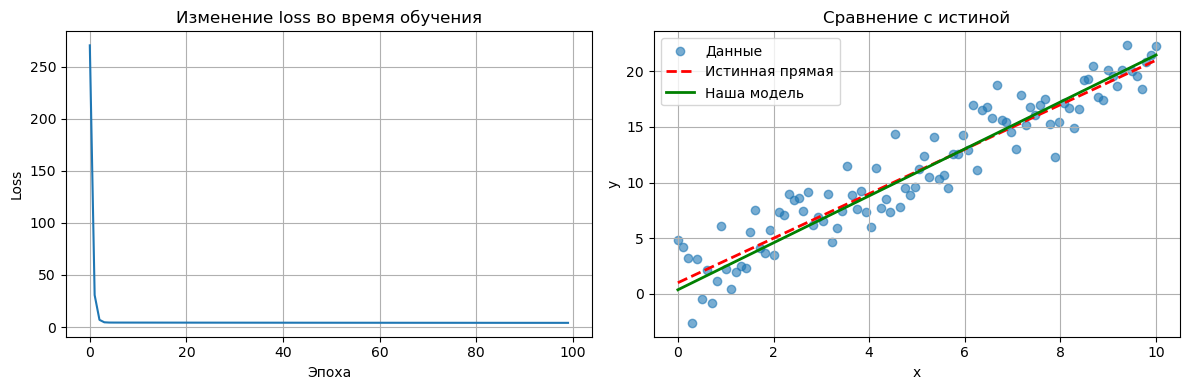

In [19]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(loss_history)
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.title('Изменение loss во время обучения')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(x, y, alpha=0.6, label='Данные')
plt.plot(x, (true_w * x + true_b).detach(), 'r--', linewidth=2, label='Истинная прямая')
plt.plot(x, (w * x + b).detach(), 'g-', linewidth=2, label='Наша модель')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.title('Сравнение с истиной')

plt.tight_layout()
plt.show()

# Цикл обучения с nn.Module

In [20]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [21]:
# данные (те же, что в Юните 4)
torch.manual_seed(42)
true_w = torch.tensor([2.0])
true_b = torch.tensor([1.0])
x = torch.linspace(0, 10, 100).reshape(-1, 1)
y = true_w * x + true_b + torch.randn_like(x) * 2

In [22]:
class LinearRegression(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(1, 1)


    def forward(self, x):
        return self.linear(x)

In [23]:
# модель и функция потерь
model = LinearRegression()
criterion = nn.MSELoss()

In [25]:
model = LinearRegression()
print(model.linear.weight)  # вес (тензор 1x1)
print(model.linear.bias)    # смещение (тензор размера 1)
print(model.linear.weight.requires_grad)  # True

# Используем модель
x = torch.linspace(0, 10, 100).reshape(-1, 1)

y_pred = model(x)
print(y_pred.shape)  # torch.Size([100, 1])

Parameter containing:
tensor([[-0.4309]], requires_grad=True)
Parameter containing:
tensor([-0.5987], requires_grad=True)
True
torch.Size([100, 1])


In [28]:
model = LinearRegression()
y_pred = model(x)
y_pred.T

tensor([[-0.5834, -0.6527, -0.7221, -0.7914, -0.8607, -0.9301, -0.9994, -1.0687,
         -1.1381, -1.2074, -1.2767, -1.3461, -1.4154, -1.4847, -1.5541, -1.6234,
         -1.6927, -1.7621, -1.8314, -1.9007, -1.9701, -2.0394, -2.1087, -2.1781,
         -2.2474, -2.3167, -2.3861, -2.4554, -2.5247, -2.5941, -2.6634, -2.7327,
         -2.8021, -2.8714, -2.9407, -3.0101, -3.0794, -3.1487, -3.2181, -3.2874,
         -3.3567, -3.4260, -3.4954, -3.5647, -3.6340, -3.7034, -3.7727, -3.8420,
         -3.9114, -3.9807, -4.0500, -4.1194, -4.1887, -4.2580, -4.3274, -4.3967,
         -4.4660, -4.5354, -4.6047, -4.6740, -4.7434, -4.8127, -4.8820, -4.9514,
         -5.0207, -5.0900, -5.1594, -5.2287, -5.2980, -5.3674, -5.4367, -5.5060,
         -5.5754, -5.6447, -5.7140, -5.7834, -5.8527, -5.9220, -5.9914, -6.0607,
         -6.1300, -6.1994, -6.2687, -6.3380, -6.4074, -6.4767, -6.5460, -6.6154,
         -6.6847, -6.7540, -6.8234, -6.8927, -6.9620, -7.0314, -7.1007, -7.1700,
         -7.2394, -7.3087, -

In [29]:
model = LinearRegression()

for param in model.parameters():
    print(param.shape)
    print(param.data)

torch.Size([1, 1])
tensor([[-0.3423]])
torch.Size([1])
tensor([-0.7893])


In [30]:
for name, param in model.named_parameters():
    print(f"{name}: {param.shape}")

# Вывод
# linear.weight: torch.Size([1, 1])
# linear.bias: torch.Size([1])

linear.weight: torch.Size([1, 1])
linear.bias: torch.Size([1])


In [31]:
model.state_dict()

OrderedDict([('linear.weight', tensor([[-0.3423]])),
             ('linear.bias', tensor([-0.7893]))])

In [32]:
# Данные из Урока 4
x = torch.linspace(0, 10, 100).reshape(-1, 1)

# Прямой проход
y_pred = model(x)

In [33]:
x.T

tensor([[ 0.0000,  0.1010,  0.2020,  0.3030,  0.4040,  0.5051,  0.6061,  0.7071,
          0.8081,  0.9091,  1.0101,  1.1111,  1.2121,  1.3131,  1.4141,  1.5152,
          1.6162,  1.7172,  1.8182,  1.9192,  2.0202,  2.1212,  2.2222,  2.3232,
          2.4242,  2.5253,  2.6263,  2.7273,  2.8283,  2.9293,  3.0303,  3.1313,
          3.2323,  3.3333,  3.4343,  3.5354,  3.6364,  3.7374,  3.8384,  3.9394,
          4.0404,  4.1414,  4.2424,  4.3434,  4.4444,  4.5455,  4.6465,  4.7475,
          4.8485,  4.9495,  5.0505,  5.1515,  5.2525,  5.3535,  5.4545,  5.5556,
          5.6566,  5.7576,  5.8586,  5.9596,  6.0606,  6.1616,  6.2626,  6.3636,
          6.4646,  6.5657,  6.6667,  6.7677,  6.8687,  6.9697,  7.0707,  7.1717,
          7.2727,  7.3737,  7.4747,  7.5758,  7.6768,  7.7778,  7.8788,  7.9798,
          8.0808,  8.1818,  8.2828,  8.3838,  8.4848,  8.5859,  8.6869,  8.7879,
          8.8889,  8.9899,  9.0909,  9.1919,  9.2929,  9.3939,  9.4949,  9.5960,
          9.6970,  9.7980,  

In [37]:
y.T

tensor([[ 4.8538,  4.1766,  3.2055, -2.6050,  3.1649, -0.4590,  2.1260, -0.7952,
          1.1119,  6.1156,  2.2352,  0.4150,  1.9685,  2.5074,  2.2906,  5.5552,
          7.5170,  4.1151,  3.6416,  5.7176,  3.5241,  7.3991,  7.0460,  9.0077,
          8.4067,  8.6434,  7.4735,  9.1240,  6.1933,  6.9421,  6.5575,  8.9823,
          4.6953,  5.9242,  7.4220, 11.5054,  8.9105,  7.6257,  9.2882,  7.3296,
          5.9657, 11.2741,  7.7253,  8.4846,  7.3406, 14.3365,  7.8236,  9.5191,
          8.8693,  9.5827, 11.2571, 12.3546, 10.5291, 14.0898, 10.2811, 10.6391,
          9.5066, 12.5872, 12.5902, 14.2704, 12.9256, 17.0124, 11.1562, 16.4944,
         16.8196, 15.8441, 18.7695, 15.5817, 15.4307, 14.5447, 13.0322, 17.8994,
         15.2011, 16.7951, 16.0627, 17.0041, 17.5035, 15.2721, 12.3448, 15.4580,
         17.1834, 16.6862, 14.8843, 16.5969, 19.2512, 19.3382, 20.5076, 17.6755,
         17.4203, 20.1284, 19.5573, 18.6686, 20.1157, 22.3342, 19.9873, 19.5847,
         18.4211, 20.8426, 2

In [34]:
y_pred.T

tensor([[-0.7893, -0.8239, -0.8584, -0.8930, -0.9276, -0.9622, -0.9967, -1.0313,
         -1.0659, -1.1005, -1.1350, -1.1696, -1.2042, -1.2388, -1.2733, -1.3079,
         -1.3425, -1.3771, -1.4116, -1.4462, -1.4808, -1.5154, -1.5499, -1.5845,
         -1.6191, -1.6537, -1.6882, -1.7228, -1.7574, -1.7920, -1.8265, -1.8611,
         -1.8957, -1.9303, -1.9648, -1.9994, -2.0340, -2.0686, -2.1031, -2.1377,
         -2.1723, -2.2069, -2.2415, -2.2760, -2.3106, -2.3452, -2.3798, -2.4143,
         -2.4489, -2.4835, -2.5181, -2.5526, -2.5872, -2.6218, -2.6564, -2.6909,
         -2.7255, -2.7601, -2.7947, -2.8292, -2.8638, -2.8984, -2.9330, -2.9675,
         -3.0021, -3.0367, -3.0713, -3.1058, -3.1404, -3.1750, -3.2096, -3.2441,
         -3.2787, -3.3133, -3.3479, -3.3824, -3.4170, -3.4516, -3.4862, -3.5207,
         -3.5553, -3.5899, -3.6245, -3.6590, -3.6936, -3.7282, -3.7628, -3.7973,
         -3.8319, -3.8665, -3.9011, -3.9357, -3.9702, -4.0048, -4.0394, -4.0740,
         -4.1085, -4.1431, -

In [38]:
x.shape, y.shape, y_pred.shape

(torch.Size([100, 1]), torch.Size([100, 1]), torch.Size([100, 1]))

In [39]:
x_small = torch.linspace(0, 10, 10).reshape(-1, 1)
y_small = model(x_small)
print(y_small.shape)  # torch.Size([10, 1])

torch.Size([10, 1])


In [40]:
import torch.nn as nn

criterion = nn.MSELoss()

In [41]:
# Предсказания модели
y_pred = model(x)

# Считаем loss одной строкой
loss = criterion(y_pred, y)

In [43]:
# гиперпараметры
learning_rate = 0.01
epochs = 100

In [44]:
# сохраняем историю loss
loss_history = []

for epoch in range(epochs):
    # прямой проход
    y_pred = model(x)
    loss = criterion(y_pred, y)
    loss_history.append(loss.item())

    # обратный проход
    loss.backward()

    # обновление весов (вручную, пока без оптимизатора)
    with torch.no_grad():
        for param in model.parameters():
            param -= learning_rate * param.grad

    # обнуление градиентов
    model.zero_grad()

    if (epoch + 1) % 20 == 0:
        print(f"Эпоха {epoch + 1}/{epochs}, Loss: {loss.item():.4f}")

Эпоха 20/100, Loss: 4.3771
Эпоха 40/100, Loss: 4.2823
Эпоха 60/100, Loss: 4.2045
Эпоха 80/100, Loss: 4.1408
Эпоха 100/100, Loss: 4.0886


In [45]:
print(f"Истинный вес: {true_w.item():.4f}")
print(f"Полученный вес: {model.linear.weight.item():.4f}")
print(f"Истинное смещение: {true_b.item():.4f}")
print(f"Полученное смещение: {model.linear.bias.item():.4f}")

Истинный вес: 2.0000
Полученный вес: 2.1328
Истинное смещение: 1.0000
Полученное смещение: 0.2169


Визуализируем обучение

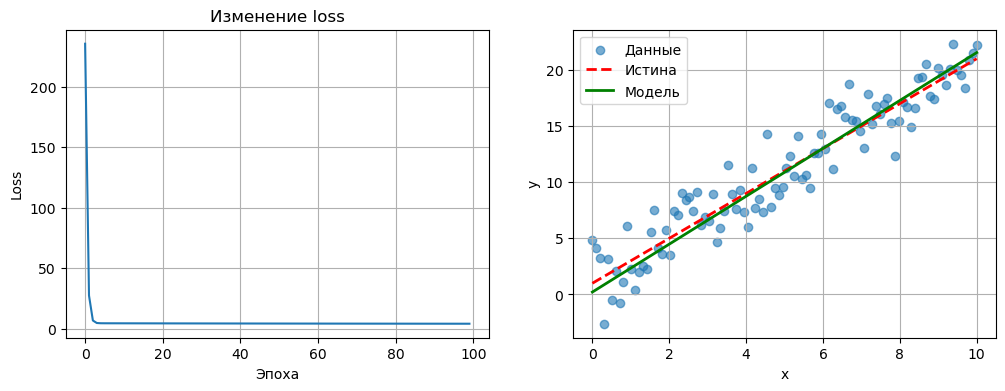

In [47]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(loss_history)
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.title('Изменение loss')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(x, y, alpha=0.6, label='Данные')
plt.plot(x, (true_w * x + true_b).detach(), 'r--', linewidth=2, label='Истина')
plt.plot(x, model(x).detach(), 'g-', linewidth=2, label='Модель')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)

plt.show()

In [48]:
# сохраняем параметры в файл
torch.save(model.state_dict(), 'linear_model.pth')

In [49]:
# создаём модель с той же архитектурой
loaded_model = LinearRegression()

# загружаем параметры
loaded_model.load_state_dict(torch.load('linear_model.pth', weights_only=True))

<All keys matched successfully>

In [50]:
# сравниваем предсказания
with torch.no_grad():
    original_pred = model(x)
    loaded_pred = loaded_model(x)

print(torch.allclose(original_pred, loaded_pred))  # True

True


In [51]:
# так тоже можно, но не рекомендуется
torch.save(model, 'model_full.pth')
